In [787]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [788]:
df_test=pd.read_csv('dataset/test.csv')

In [789]:
df_train = pd.read_csv('dataset/train.csv')

In [790]:
df_train['is_train'] = 1
df_test['is_train'] = 0

# Combine them into a single comprehensive master dataframe
# Pandas handles the missing 'demand' column in df_test by assigning it NaN
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

In [791]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,1
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,1
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,1
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,1
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,1


In [792]:
df['day'].value_counts()

day
48    69427
49    49650
Name: count, dtype: int64

In [793]:
df_train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
is_train            0
dtype: int64

In [794]:
df.isnull().sum()

Index                0
geohash              0
day                  0
timestamp            0
demand           41778
RoadType           924
NumberofLanes        0
LargeVehicles        0
Landmarks            0
Temperature       3844
Weather           1228
is_train             0
dtype: int64

In [795]:
df['Weather'].value_counts()

Weather
Sunny    42795
Rainy    31905
Foggy    31345
Snowy    11804
Name: count, dtype: int64

In [796]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119077 entries, 0 to 119076
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Index          119077 non-null  int64  
 1   geohash        119077 non-null  str    
 2   day            119077 non-null  int64  
 3   timestamp      119077 non-null  str    
 4   demand         77299 non-null   float64
 5   RoadType       118153 non-null  str    
 6   NumberofLanes  119077 non-null  int64  
 7   LargeVehicles  119077 non-null  str    
 8   Landmarks      119077 non-null  str    
 9   Temperature    115233 non-null  float64
 10  Weather        117849 non-null  str    
 11  is_train       119077 non-null  int64  
dtypes: float64(2), int64(4), str(6)
memory usage: 10.9 MB


In [797]:
df['Temperature'].min(), df['Temperature'].max()

(np.float64(-21.314644566266928), np.float64(48.2514326535093))

In [798]:

df['hour'] = pd.to_datetime(df['timestamp'], format='%H:%M').dt.hour

# CRITICAL: Sort chronologically by location so forward-fill works flawlessly first
df = df.sort_values(by=['geohash', 'day', 'timestamp']).reset_index(drop=True)

# STEP 1: Local Time Fill (Immediate neighbors in time)
df['Temperature'] = df.groupby('geohash')['Temperature'].ffill().bfill()
df['Weather'] = df.groupby('geohash')['Weather'].ffill().bfill()


# # STEP 2: Your Upgrade! (Precise Location + Hour Profile)
# # If a whole day is missing, fill it with the historical median for that location AT THAT HOUR
# df['Temperature'] = df['Temperature'].fillna(
#     df.groupby(['geohash', 'hour'])['Temperature'].transform('median')
# )

# df['Weather'] = df['Weather'].fillna(
#     df.groupby(['geohash', 'hour'])['Weather'].transform(
#         lambda x: x.mode()[0] if not x.mode().empty else np.nan
#     )
# )


# # STEP 3: Regional Safety Net
# # If that specific hour-location profile doesn't exist yet, zoom out to the broader neighborhood region
# df['broad_region'] = df['geohash'].str[:4]

# df['Temperature'] = df['Temperature'].fillna(
#     df.groupby(['broad_region', 'day', 'hour'])['Temperature'].transform('median')
# )
# df['Weather'] = df['Weather'].fillna(
#     df.groupby(['broad_region', 'day', 'hour'])['Weather'].transform(
#         lambda x: x.mode()[0] if not x.mode().empty else np.nan
#     )
# )


# # STEP 4: Absolute Global Fallback
# # Final safety check so LightGBM doesn't encounter a single NaN
# df['Temperature'] = df['Temperature'].fillna(df.groupby('hour')['Temperature'].transform('median'))
# df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

In [799]:
# Count how many temperatures are negative
negative_count = (df['Temperature'] < 7.8).sum()
print(f"Total number of negative temperatures: {negative_count}")

Total number of negative temperatures: 14396


In [800]:
print(df[df['Temperature'] < 0][['day', 'hour', 'Weather', 'Temperature']].drop_duplicates().head(20))

      day  hour Weather  Temperature
24     48    11   Snowy    -3.210799
34     48     4   Snowy    -0.398511
35     48     4   Foggy    -0.398511
255    48     4   Snowy    -2.181645
317    49     9   Snowy    -1.040039
399    48    14   Snowy    -1.224649
486    48     6   Snowy    -4.463081
487    48     6   Foggy    -4.463081
630    49     9   Snowy    -0.734796
686    49    10   Snowy    -3.375016
768    48     2   Snowy    -2.110693
1143   48     5   Snowy    -1.894658
1178   49     2   Snowy    -1.143708
1211   48    11   Snowy    -8.879868
1224   48     1   Snowy    -7.264083
1420   48    10   Snowy    -4.165889
1464   49     3   Snowy    -1.636239
1563   49     1   Snowy    -0.909528
1591   49     8   Snowy    -0.157171
1697   48     0   Snowy    -0.794609


In [801]:
df.isnull().sum()

Index                0
geohash              0
day                  0
timestamp            0
demand           41778
RoadType           924
NumberofLanes        0
LargeVehicles        0
Landmarks            0
Temperature          0
Weather              0
is_train             0
hour                 0
dtype: int64

In [802]:


# 2. Regional Safety Net (If an entire geohash location is missing its RoadType everywhere)
# Extract a broader region (first 4 characters of geohash) to look at neighboring streets
df['broad_region'] = df['geohash'].str[:4]

df['RoadType'] = df['RoadType'].fillna(
    df.groupby('broad_region')['RoadType'].transform(
        lambda x: x.mode()[0] 
    )
)

# # 3. Absolute Global Fallback (Just in case)
# df['RoadType'] = df['RoadType'].fillna(df['RoadType'].mode()[0])

In [803]:
df.isnull().sum()

Index                0
geohash              0
day                  0
timestamp            0
demand           41778
RoadType             0
NumberofLanes        0
LargeVehicles        0
Landmarks            0
Temperature          0
Weather              0
is_train             0
hour                 0
broad_region         0
dtype: int64

In [804]:
temp_time = pd.to_datetime(df['timestamp'], format='%H:%M').dt

df['hour'] = temp_time.hour
df['minute'] = temp_time.minute
    

    

In [805]:
df['minutes_since_midnight'] = df['hour'] * 60 + df['minute']

In [806]:
# Cyclical encoding (The clock-face loop)
# This mathematically maps 23:45 right next to 00:00
df['sin_time'] = np.sin(2 * np.pi * df['minutes_since_midnight'] / 1440)
df['cos_time'] = np.cos(2 * np.pi * df['minutes_since_midnight'] / 1440)

In [807]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train,hour,broad_region,minute,minutes_since_midnight,sin_time,cos_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,Sunny,1,10,qp02,30,630,0.382683,-0.923880
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,Foggy,1,10,qp02,45,645,0.321439,-0.946930
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,Rainy,1,1,qp02,0,60,0.258819,0.965926
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,Sunny,1,2,qp02,30,150,0.608761,0.793353
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,Foggy,1,2,qp02,45,165,0.659346,0.751840


In [808]:
import seaborn as sns

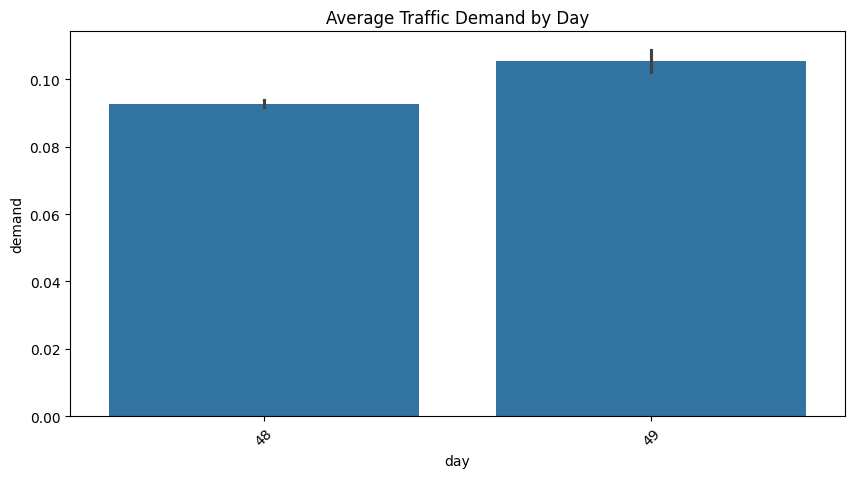

In [809]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='day',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Average Traffic Demand by Day')
plt.xticks(rotation=45)

plt.show()

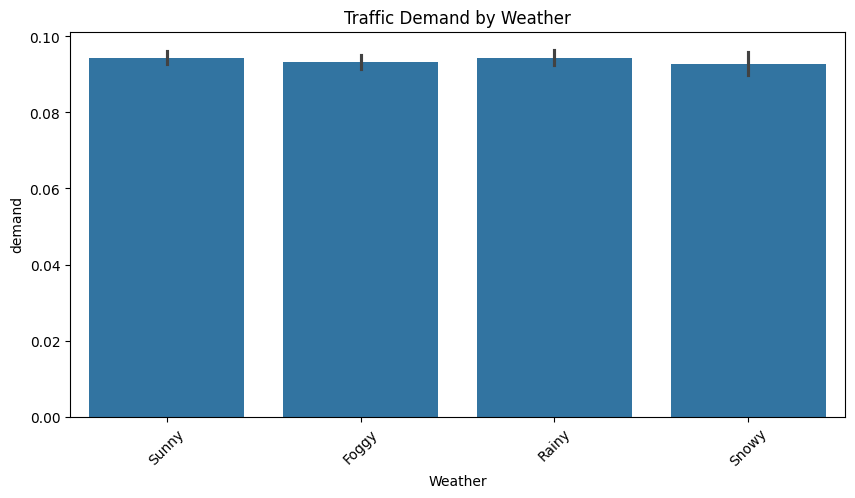

In [810]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Weather',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Traffic Demand by Weather')
plt.xticks(rotation=45)

plt.show()

In [811]:
df['Temperature'].min(), df['Temperature'].max()

(np.float64(-21.314644566266928), np.float64(48.2514326535093))

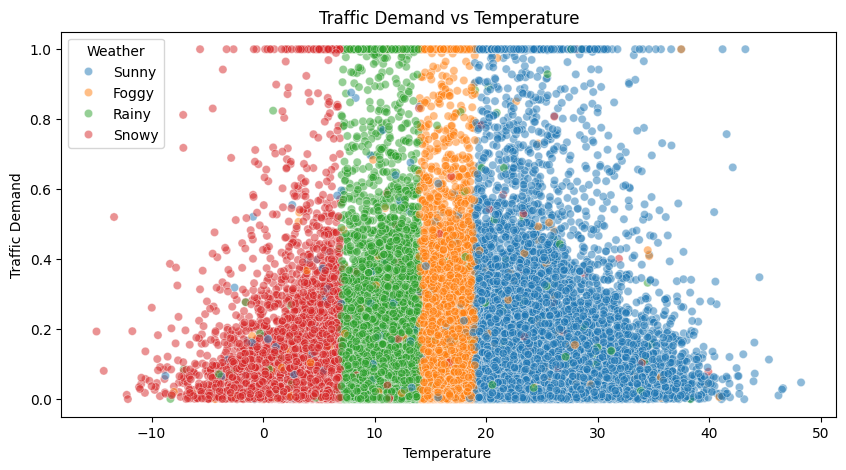

In [812]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Temperature',
    y='demand',
    hue='Weather',
    data=df,
    alpha=0.5
)
plt.title('Traffic Demand vs Temperature')


plt.xlabel('Temperature ')
plt.ylabel('Traffic Demand')
plt.show()

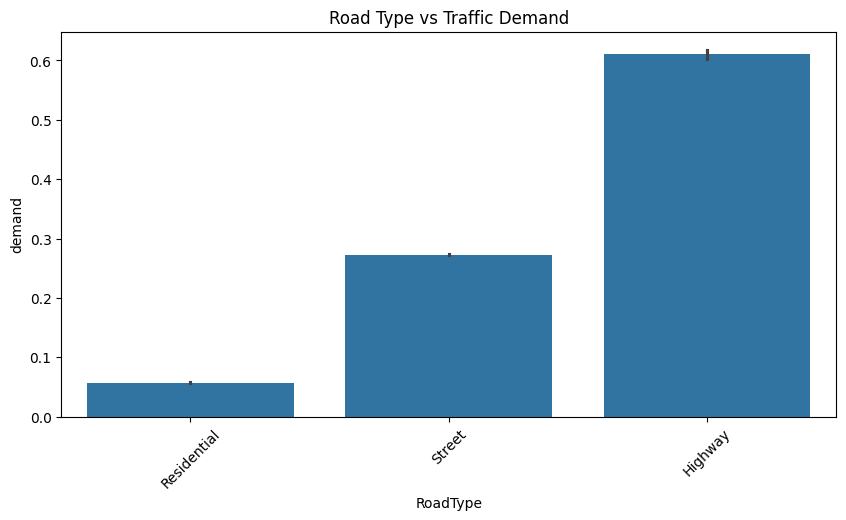

In [813]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='RoadType',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Road Type vs Traffic Demand')

plt.xticks(rotation=45)

plt.show()

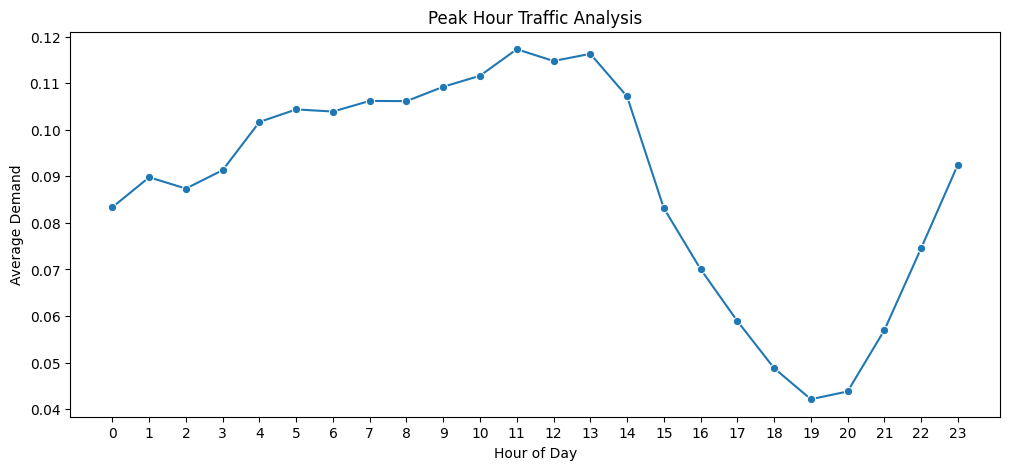

In [814]:
hourly_demand = df.groupby('hour')['demand'].mean().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    x='hour',
    y='demand',
    data=hourly_demand,
    marker='o'
)

plt.title('Peak Hour Traffic Analysis')

plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')

plt.xticks(range(0,24))

plt.show()

In [815]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train,hour,broad_region,minute,minutes_since_midnight,sin_time,cos_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,Sunny,1,10,qp02,30,630,0.382683,-0.923880
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,Foggy,1,10,qp02,45,645,0.321439,-0.946930
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,Rainy,1,1,qp02,0,60,0.258819,0.965926
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,Sunny,1,2,qp02,30,150,0.608761,0.793353
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,Foggy,1,2,qp02,45,165,0.659346,0.751840


In [816]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119077 entries, 0 to 119076
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Index                   119077 non-null  int64  
 1   geohash                 119077 non-null  str    
 2   day                     119077 non-null  int64  
 3   timestamp               119077 non-null  str    
 4   demand                  77299 non-null   float64
 5   RoadType                119077 non-null  str    
 6   NumberofLanes           119077 non-null  int64  
 7   LargeVehicles           119077 non-null  str    
 8   Landmarks               119077 non-null  str    
 9   Temperature             119077 non-null  float64
 10  Weather                 119077 non-null  str    
 11  is_train                119077 non-null  int64  
 12  hour                    119077 non-null  int32  
 13  broad_region            119077 non-null  str    
 14  minute                  119077 

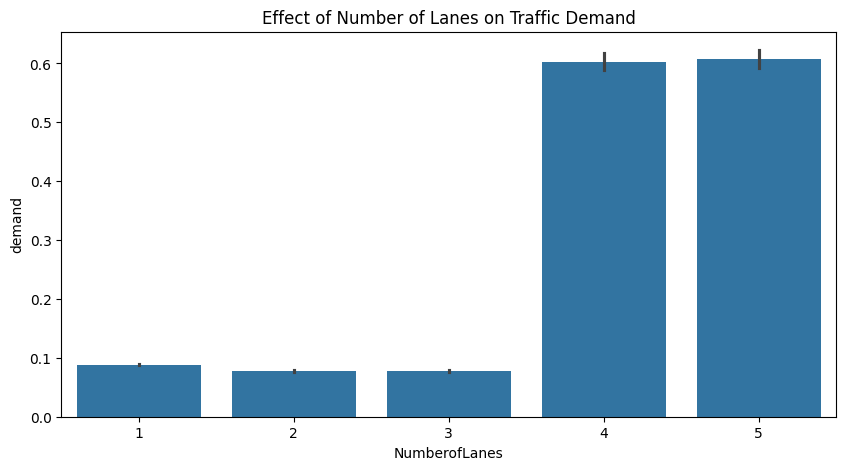

In [817]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='NumberofLanes',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Effect of Number of Lanes on Traffic Demand')

plt.show()

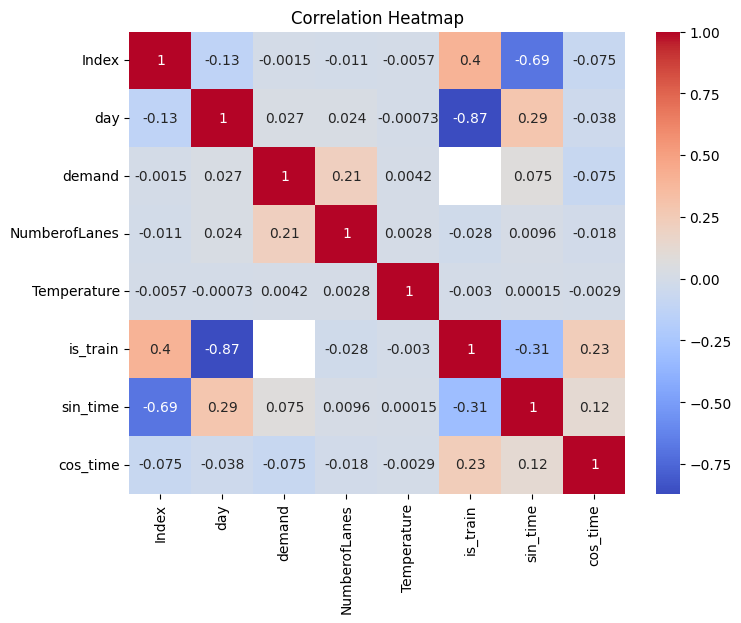

In [818]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

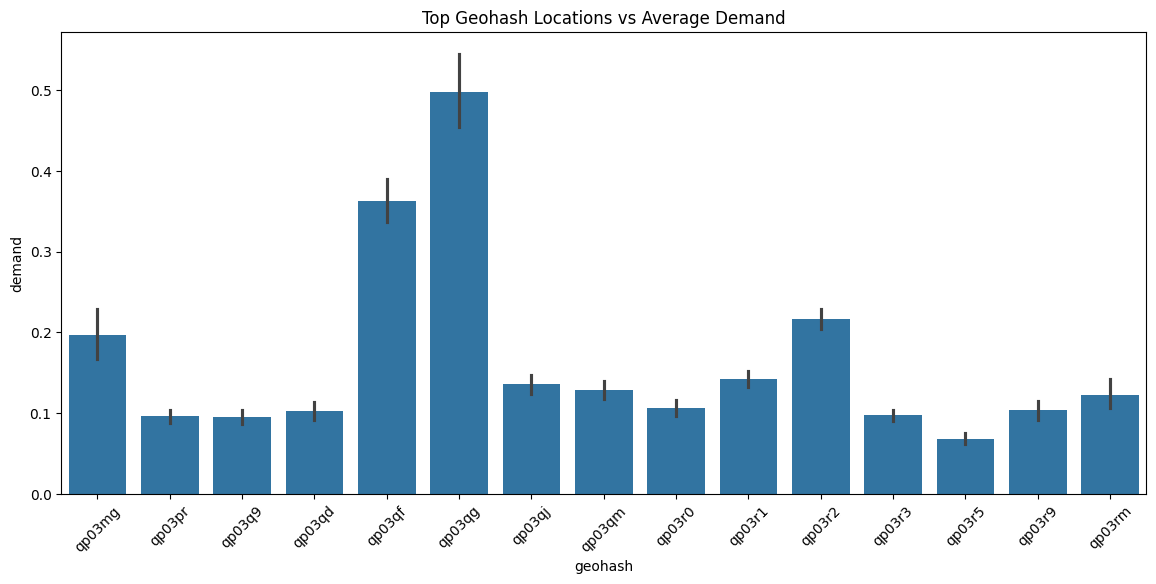

In [819]:
top_geohash = df['geohash'].value_counts().head(15).index

filtered_df = df[df['geohash'].isin(top_geohash)]

plt.figure(figsize=(14,6))

sns.barplot(
    x='geohash',
    y='demand',
    data=filtered_df,
    estimator='mean'
)

plt.title('Top Geohash Locations vs Average Demand')

plt.xticks(rotation=45)

plt.show()

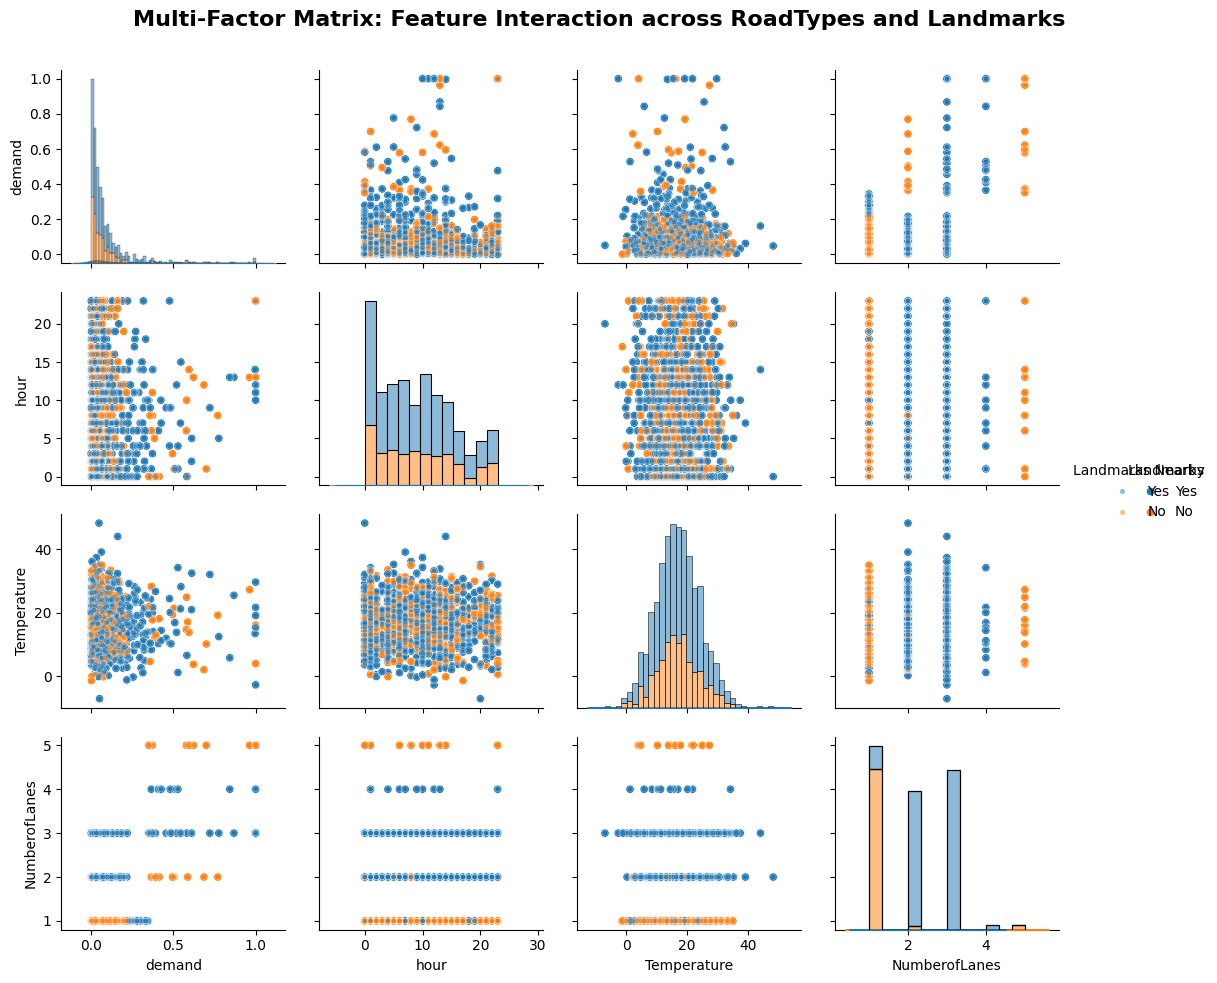

In [820]:
train_data = df[df['is_train'] == 1].copy()

# 2. Downsample randomly so the grid renders quickly without lagging your notebook
# (Processing a multi-categorical matrix on 77k+ rows takes a lot of memory)
train_sample = train_data.sample(n=1200, random_state=42)

# 3. Choose the numerical features you want to look at on the axes
numerical_vars = ['demand', 'hour', 'Temperature', 'NumberofLanes']

# 4. Initialize the custom PairGrid 
# col='RoadType' splits the plots side-by-side for each road layout
# hue='Landmarks' applies separate colors for landmark status
# ensure the sampled frame has an 'hour' (pairplot needs it)
train_sample = train_sample.copy()
if 'hour' not in train_sample.columns:
    temp = pd.to_datetime(train_sample['timestamp'], format='%H:%M', errors='coerce')
    if temp.isna().any():
        # fallback for non-zero-padded times like "1:0"
        temp = pd.to_datetime(train_sample['timestamp'], errors='coerce')
    train_sample['hour'] = temp.dt.hour
    train_sample['minute'] = temp.dt.minute
    train_sample['minutes_since_midnight'] = train_sample['hour'] * 60 + train_sample['minute']

# initialize a PairGrid faceted by RoadType, colored by Landmarks
g = sns.pairplot(
    train_sample,
    vars=numerical_vars,
    hue='Landmarks',
    
)

# 5. Map scatter plots to the off-diagonal intersection squares
g.map_offdiag(sns.scatterplot, alpha=0.5, s=15)

# 6. Map histograms to the diagonal squares to show separate feature distributions
g.map_diag(sns.histplot, multiple="stack", alpha=0.5)

# 7. Add a clean layout adjustments and a unified legend
g.add_legend(title="Landmarks Nearby", adjust_subtitles=True)
g.fig.subplots_adjust(top=0.92, wspace=0.15, hspace=0.15)
g.fig.suptitle('Multi-Factor Matrix: Feature Interaction across RoadTypes and Landmarks', fontsize=16, weight='bold')

# 8. Render the final plot matrix
plt.show()

In [821]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train,hour,broad_region,minute,minutes_since_midnight,sin_time,cos_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,Sunny,1,10,qp02,30,630,0.382683,-0.923880
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,Foggy,1,10,qp02,45,645,0.321439,-0.946930
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,Rainy,1,1,qp02,0,60,0.258819,0.965926
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,Sunny,1,2,qp02,30,150,0.608761,0.793353
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,Foggy,1,2,qp02,45,165,0.659346,0.751840


In [822]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119077 entries, 0 to 119076
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Index                   119077 non-null  int64  
 1   geohash                 119077 non-null  str    
 2   day                     119077 non-null  int64  
 3   timestamp               119077 non-null  str    
 4   demand                  77299 non-null   float64
 5   RoadType                119077 non-null  str    
 6   NumberofLanes           119077 non-null  int64  
 7   LargeVehicles           119077 non-null  str    
 8   Landmarks               119077 non-null  str    
 9   Temperature             119077 non-null  float64
 10  Weather                 119077 non-null  str    
 11  is_train                119077 non-null  int64  
 12  hour                    119077 non-null  int32  
 13  broad_region            119077 non-null  str    
 14  minute                  119077 

In [823]:
import geohash2

# Extract latitude and longitude from geohash
df['latitude'] = df['geohash'].apply(lambda x: geohash2.decode(x)[0])
df['longitude'] = df['geohash'].apply(lambda x: geohash2.decode(x)[1])

# Display the results
df[['geohash', 'latitude', 'longitude']].head()

,geohash,latitude,longitude
0,qp02yc,-5.48,90.7
1,qp02yc,-5.48,90.7
2,qp02yc,-5.48,90.7
3,qp02yc,-5.48,90.7
4,qp02yc,-5.48,90.7


In [824]:
import lightgbm as lgb
import pygeohash as pgh
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

In [825]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
df['geohash_time_slot'] = df['geohash'].astype(str) + "_" + df['minutes_since_midnight'].astype(str)

df['te_geohash_time'] = np.nan
df['te_geohash_time'] = df['te_geohash_time'].astype('float64')

train_indices = df[df['is_train'] == 1].index
test_indices = df[df['is_train'] == 0].index

global_mean = float(df.loc[train_indices, 'demand'].mean())


kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(train_indices):
    actual_train_idx = train_indices[train_idx]
    actual_val_idx = train_indices[val_idx]
    
    fold_train_stats = df.loc[actual_train_idx].groupby('geohash_time_slot')['demand'].mean()
    
    df.loc[actual_val_idx, 'te_geohash_time'] = df.loc[actual_val_idx, 'geohash_time_slot'].map(fold_train_stats).astype('float64')

df.loc[train_indices, 'te_geohash_time'] = df.loc[train_indices, 'te_geohash_time'].fillna(global_mean)


full_training_stats = df.loc[train_indices].groupby('geohash_time_slot')['demand'].mean()
df.loc[test_indices, 'te_geohash_time'] = df.loc[test_indices, 'geohash_time_slot'].map(full_training_stats).astype('float64')

df.loc[test_indices, 'te_geohash_time'] = df.loc[test_indices, 'te_geohash_time'].fillna(global_mean)

# 5. Drop the temporary cross-product string column
df.drop(columns=['geohash_time_slot'], inplace=True)

In [826]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,is_train,hour,broad_region,minute,minutes_since_midnight,sin_time,cos_time,latitude,longitude,te_geohash_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,...,1,10,qp02,30,630,0.382683,-0.923880,-5.48,90.7,0.093942
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,...,1,10,qp02,45,645,0.321439,-0.946930,-5.48,90.7,0.093942
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,...,1,1,qp02,0,60,0.258819,0.965926,-5.48,90.7,0.093942
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,...,1,2,qp02,30,150,0.608761,0.793353,-5.48,90.7,0.093942
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,...,1,2,qp02,45,165,0.659346,0.751840,-5.48,90.7,0.093942


In [827]:
df.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather',
       'is_train', 'hour', 'broad_region', 'minute', 'minutes_since_midnight',
       'sin_time', 'cos_time', 'latitude', 'longitude', 'te_geohash_time'],
      dtype='str')

In [828]:
# Crucial: Sort data so consecutive rows represent consecutive time steps for the same location
df = df.sort_values(by=['geohash', 'day', 'minutes_since_midnight']).reset_index(drop=True)

df['demand_lag_1'] = df.groupby(['geohash'])['demand'].shift(96)

# 2. Create Lag 2 (Demand from 2 time slots ago at that geohash)
df['demand_lag_2'] = df.groupby(['geohash'])['demand'].shift(192)

# 3. Create a Rolling Mean (Average demand over the last 3 time slots)
# 'closed="left"' is critical to prevent the model from seeing the current row's demand!
df['demand_rolling_mean_3'] = df.groupby(['geohash'])['demand'].transform(
    lambda x: x.shift(1).rolling(window=96, min_periods=1).mean()
)

In [829]:
df['is_train'].head(100000)

0        1
1        1
2        1
3        1
4        1
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: is_train, Length: 100000, dtype: int64

In [830]:
# Fill any edge-case missing lags using the historical time slot average as a fallback
df['demand_lag_1'] = df['demand_lag_1'].fillna(df['te_geohash_time'])
df['demand_lag_2'] = df['demand_lag_2'].fillna(df['te_geohash_time'])
df['demand_rolling_mean_3'] = df['demand_rolling_mean_3'].fillna(df['te_geohash_time'])

In [831]:
# # Assuming your time slots are 15 minutes long, there are 96 slots in 24 hours
# # Shift by 96 steps to look back exactly 1 day ago
# df['demand_lag_1_day'] = df.groupby(['geohash'])['demand'].shift(96)

# # Shift by 192 steps to look back exactly 2 days ago
# df['demand_lag_2_days'] = df.groupby(['geohash'])['demand'].shift(192)

# # Fill any missing values at the start of the data with your historical average
# df['demand_lag_1_day'] = df['demand_lag_1_day'].fillna(df['te_geohash_time'])
# df['demand_lag_2_days'] = df['demand_lag_2_days'].fillna(df['te_geohash_time'])

In [832]:
import lightgbm as lgb
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split


In [833]:
categorical_cols = ['Weather', 'RoadType', 'Landmarks']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, dtype=int), categorical_cols)
    ],
    remainder='passthrough'
)

In [834]:
from sklearn.ensemble import VotingRegressor

In [835]:
lgb_model=lgb.LGBMRegressor(
        n_estimators=4000,          # Increased trees to learn deeper feature combinations
        learning_rate=0.15,        # Dropped learning rate for smoother optimization convergence
        num_leaves=80,              # Increased from default 31 to allow more complex structural splits
        max_depth= 12,                # Sets a safe structural upper bound for leaf growth
        subsample=0.8,              # Randomly samples 80% of data per tree to prevent overfitting
        colsample_bytree=0.8,       # Randomly samples 80% of features per tree split
        reg_alpha=0.5,              # Bumped L1 regularization to prune out noisy tree splits
        reg_lambda=0.5,             # Bumped L2 regularization to stabilize variance
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=3000, learning_rate=0.015, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=5.0, reg_lambda=5.0,
    random_state=42, n_jobs=-1, verbosity=0
)

# CatBoost handles variance incredibly well out of the box
cat_model = CatBoostRegressor(
    iterations=3000, learning_rate=0.015, depth=8,
    l2_leaf_reg=5.0, random_seed=42, thread_count=-1, verbose=0
)

In [836]:
ensemble_meta = VotingRegressor(
    estimators=[
        ('lgb1', lgb_model),
        ('lgb2', lgb_model),
        ('lgb3', lgb_model)
    ],
    n_jobs=-1
)

In [837]:
traffic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ensemble', ensemble_meta)
])

In [838]:

features = [
    'latitude', 'longitude', 'Temperature', 'NumberofLanes', 'day', 'hour', 'minute',
    'minutes_since_midnight', 'sin_time', 'cos_time', 'te_geohash_time',
    'Weather', 'RoadType', 'Landmarks',
    'demand_lag_1', 'demand_lag_2', 'demand_rolling_mean_3' # Your new features!
]

X = df[df['is_train'] == 1][features ].copy()
Y = df[df['is_train'] == 1]['demand']

X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42)

print("Executing unified pipeline training...")

Executing unified pipeline training...


In [839]:
# 5-fold cross-validation on the training set
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = Y.iloc[tr_idx], Y.iloc[va_idx]

    traffic_pipeline.fit(X_tr, y_tr)
    y_pred = traffic_pipeline.predict(X_va)
    fold_r2 = r2_score(y_va, y_pred)
    cv_scores.append(fold_r2)

    print(f"Fold {fold} R2: {fold_r2:.4f}")

print(f"\nMean CV R2: {np.mean(cv_scores):.4f}")
print(f"Std CV R2 : {np.std(cv_scores):.4f}")

Fold 1 R2: 0.9405
Fold 2 R2: 0.9400
Fold 3 R2: 0.9402
Fold 4 R2: 0.9425
Fold 5 R2: 0.9439

Mean CV R2: 0.9414
Std CV R2 : 0.0015


In [840]:
traffic_pipeline.fit(X_train, y_train)

c:\Users\Pulkit\Banglore_traffic_prediction\venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                dtype=<class 'int'>,
                                                                sparse_output=False),
                                                  ['Weather', 'RoadType',
                                                   'Landmarks'])])),
                ('ensemble',
                 VotingRegressor(estimators=[('lgb1',
                                              LGBMRegressor(colsample_bytree=0.8,
                                                            learning_rate=0.15,
                                                            max_depth=12,
                                                            n_estimators=4000,
                                                            n_jobs=-1,
                                                            num_le...
                                              LGBMRegressor(colsample_bytree=0.8,
                                                            learning_rate=0.15,
                                                            max_depth=12,
                                                            n_estimators=4000,
                                                            n_jobs=-1,
                                                            num_leaves=80,
                                                            random_state=42,
                                                            reg_alpha=0.5,
                                                            reg_lambda=0.5,
                                                            subsample=0.8,
                                                            verbose=-1)),
                                             ('lgb3',
                                              LGBMRegressor(colsample_bytree=0.8,
                                                            learning_rate=0.15,
                                                            max_depth=12,
                                                            n_estimators=4000,
                                                            n_jobs=-1,
                                                            num_leaves=80,
                                                            random_state=42,
                                                            reg_alpha=0.5,
                                                            reg_lambda=0.5,
                                                            subsample=0.8,
                                                            verbose=-1))],
                                 n_jobs=-1))])

In [841]:
val_preds = traffic_pipeline.predict(X_val)
validation_r2 = r2_score(y_val, val_preds)

print("\n" + "="*50)
print(f"PIPELINE REGRESSOR TRAINING COMPLETE")
print(f"Validation R2 Score: {validation_r2:.4f}")
print("="*50)



PIPELINE REGRESSOR TRAINING COMPLETE
Validation R2 Score: 0.9405
